# 🤖 04 — Machine Learning
## Insurance Retention Analytics

> **Objetivo:** Entrenar y comparar 4 modelos de clasificación binaria para predecir el churn, seleccionar el modelo final basándonos en métricas alineadas con el negocio y guardarlo serializado para reutilización.

**Fase CRISP-DM:** Modeling  
**Fecha:** 2026

---

## Tabla de contenidos

1. [Setup y carga de los splits](#1-setup)
2. [Función helper de evaluación](#2-helper)
3. [Baseline trivial (regla de la mayoría)](#3-baseline)
4. [Modelo 1 — Random Forest](#4-rf)
5. [Modelo 2 — XGBoost básico](#5-xgb1)
6. [Modelo 3 — XGBoost balanceado (`scale_pos_weight=2.3`)](#6-xgb2)
7. [Modelo 4 — XGBoost mid (FINAL, `scale_pos_weight=1.5`)](#7-xgb3)
8. [Comparación final de modelos](#8-comparacion)
9. [Justificación del modelo seleccionado](#9-justificacion)
10. [Persistencia del modelo (joblib)](#10-persist)
11. [Conclusión](#11-conclusion)

---

<a id="1-setup"></a>
## 1. Setup y carga de los splits

Cargamos directamente los archivos **`.parquet`** generados en el notebook 03. **Ventaja:** ya están encodeados, con features nuevas, y el split está garantizado idéntico (mismo `random_state=42`).

In [1]:
# ============================================================
# Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

# Paleta corporativa (consistente con notebook 02)
COLORS = {"retained":"#2E86AB", "churn":"#E63946", "accent":"#F4A261",
          "neutral":"#6C757D", "good":"#06A77D"}

In [2]:
# ============================================================
# Carga de splits desde Parquet (output del notebook 03)
# ============================================================
DATA_DIR = Path("../data/processed")

X_train = pd.read_parquet(DATA_DIR / "X_train.parquet")
X_test  = pd.read_parquet(DATA_DIR / "X_test.parquet")
y_train = pd.read_parquet(DATA_DIR / "y_train.parquet")["churn_flag"]
y_test  = pd.read_parquet(DATA_DIR / "y_test.parquet")["churn_flag"]

print(f"✅ Splits cargados:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test : {X_test.shape}")
print(f"   y_train churn rate: {y_train.mean()*100:.2f}%")
print(f"   y_test  churn rate: {y_test.mean()*100:.2f}%")

✅ Splits cargados:
   X_train: (40000, 53)
   X_test : (10000, 53)
   y_train churn rate: 30.16%
   y_test  churn rate: 30.17%


<a id="2-helper"></a>
## 2. Función helper de evaluación

Definimos **una sola función** que evalúa cualquier modelo con todas las métricas relevantes. Esto nos permite comparar modelos consistentemente y mantener el código DRY (Don't Repeat Yourself).

### ¿Qué métricas usaremos y por qué?

| Métrica | Fórmula intuitiva | Cuándo importa |
|---|---|---|
| **Accuracy** | (TP+TN) / Total | Visión general — engaña en desbalance |
| **Precision (churn)** | TP / (TP+FP) | "De los que predije que se van, ¿cuántos se fueron?" → controla **costo de contacto** |
| **Recall (churn)** | TP / (TP+FN) | "De los que se fueron, ¿a cuántos detecté?" → controla **pérdida de revenue** |
| **F1 (churn)** | Media armónica de Precision y Recall | Balance global |
| **ROC-AUC** | Área bajo la curva ROC | Capacidad de discriminación independiente del threshold |
| **PR-AUC** | Área bajo la curva Precision-Recall | Más informativa que ROC en clases desbalanceadas |

> 🎓 **Concepto clave para entrevistas:** ROC-AUC puede ser engañoso en desbalance (la línea base es 0.5 con clase mayoritaria abundante). **PR-AUC es más exigente** y más realista en este caso.

In [3]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)

# Diccionario donde acumularemos los resultados de cada modelo
resultados = {}

def entrenar_y_evaluar(modelo, nombre, X_train, y_train, X_test, y_test, verbose=True):
    """
    Entrena un modelo y devuelve métricas completas.

    Devuelve un dict con: accuracy, precision, recall, f1, roc_auc, pr_auc,
    confusion_matrix, y el modelo entrenado.
    """
    # Entrenamiento
    modelo.fit(X_train, y_train)

    # Predicciones (clase y probabilidad)
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    # Métricas
    metricas = {
        "modelo"    : nombre,
        "accuracy"  : accuracy_score(y_test, y_pred),
        "precision" : precision_score(y_test, y_pred),
        "recall"    : recall_score(y_test, y_pred),
        "f1"        : f1_score(y_test, y_pred),
        "roc_auc"   : roc_auc_score(y_test, y_proba),
        "pr_auc"    : average_precision_score(y_test, y_proba),
        "cm"        : confusion_matrix(y_test, y_pred),
        "estimator" : modelo,
    }

    if verbose:
        print(f"\n{'='*55}")
        print(f"📊  {nombre}")
        print(f"{'='*55}")
        print(f"  Accuracy   : {metricas['accuracy']:.4f}")
        print(f"  Precision  : {metricas['precision']:.4f}")
        print(f"  Recall     : {metricas['recall']:.4f}")
        print(f"  F1-score   : {metricas['f1']:.4f}")
        print(f"  ROC-AUC    : {metricas['roc_auc']:.4f}")
        print(f"  PR-AUC     : {metricas['pr_auc']:.4f}")
        cm = metricas['cm']
        print(f"\n  Matriz de confusión:")
        print(f"                Predicho 0    Predicho 1")
        print(f"  Real 0 (RET):   {cm[0,0]:>7,}      {cm[0,1]:>7,}")
        print(f"  Real 1 (CHN):   {cm[1,0]:>7,}      {cm[1,1]:>7,}")

    return metricas

<a id="3-baseline"></a>
## 3. Baseline trivial: regla de la mayoría

Antes de entrenar modelos complejos, calculamos el **baseline más simple posible**: predecir siempre la clase mayoritaria (retenido). Esto nos da el **piso mínimo** que cualquier modelo debe superar.

> 🎓 **Importante:** sin un baseline, no sabes si tu modelo es bueno. Un modelo con 70% de accuracy en un dataset 70/30 **no aprendió nada** — simplemente predice la clase mayoritaria.

In [4]:
# Baseline: predecir siempre clase 0 (retenido)
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
res_dummy = entrenar_y_evaluar(dummy, "🎲 Baseline (mayoría = clase 0)",
                                X_train, y_train, X_test, y_test)
resultados["baseline"] = res_dummy


📊  🎲 Baseline (mayoría = clase 0)
  Accuracy   : 0.6983
  Precision  : 0.0000
  Recall     : 0.0000
  F1-score   : 0.0000
  ROC-AUC    : 0.5000
  PR-AUC     : 0.3017

  Matriz de confusión:
                Predicho 0    Predicho 1
  Real 0 (RET):     6,983            0
  Real 1 (CHN):     3,017            0


**Lectura:** el baseline acierta el ~70% de los casos pero tiene **Recall = 0 en churn** (no detecta a ningún churner). Cualquier modelo decente debe superar al menos el F1 = 0 del baseline, lo cual no es difícil — pero el **F1 = 0** ayuda a interpretar el ranking.

<a id="4-rf"></a>
## 4. Modelo 1 — Random Forest (baseline ML)

**Random Forest** es un ensamblado de árboles de decisión que vota por mayoría. Es el modelo "navaja suiza" que todo data scientist prueba primero:

- ✅ Robusto a outliers y a escalas distintas
- ✅ No requiere normalización
- ✅ Maneja interacciones no lineales
- ✅ Da feature importance gratis
- ⚠️ Puede sobreajustar con muchos árboles profundos

> 💡 **Hiperparámetros usados:** `n_estimators=100` (100 árboles), `random_state=42` (reproducibilidad).

In [5]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,    # 100 árboles
    random_state=42,
    n_jobs=-1            # usar todos los cores del CPU
)

res_rf = entrenar_y_evaluar(modelo_rf, "🌳 Random Forest",
                             X_train, y_train, X_test, y_test)
resultados["random_forest"] = res_rf


📊  🌳 Random Forest
  Accuracy   : 0.7659
  Precision  : 0.6934
  Recall     : 0.4017
  F1-score   : 0.5087
  ROC-AUC    : 0.7789
  PR-AUC     : 0.6460

  Matriz de confusión:
                Predicho 0    Predicho 1
  Real 0 (RET):     6,447          536
  Real 1 (CHN):     1,805        1,212


<a id="5-xgb1"></a>
## 5. Modelo 2 — XGBoost básico

**XGBoost (Extreme Gradient Boosting)** es el **algoritmo dorado de competencias** y producción para problemas tabulares:

- 🚀 Construye árboles **secuencialmente**, cada uno corrigiendo los errores del anterior
- ⚡ Implementación altamente optimizada (paraleliza la construcción de cada árbol)
- 🎯 Suele superar a Random Forest en problemas tabulares
- 🎛️ Muchos hiperparámetros (control fino del aprendizaje)

> 📚 **Por qué se llama "gradient boosting":** cada árbol nuevo aprende a corregir el error residual (el gradiente de la función de pérdida) del modelo previo.

In [6]:
from xgboost import XGBClassifier

modelo_xgb1 = XGBClassifier(
    n_estimators=200,        # 200 árboles
    max_depth=5,             # profundidad moderada → menos overfit
    learning_rate=0.05,      # cuánto "aprende" cada árbol
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

res_xgb1 = entrenar_y_evaluar(modelo_xgb1, "⚡ XGBoost básico",
                               X_train, y_train, X_test, y_test)
resultados["xgboost_basico"] = res_xgb1


📊  ⚡ XGBoost básico
  Accuracy   : 0.7715
  Precision  : 0.7077
  Recall     : 0.4133
  F1-score   : 0.5219
  ROC-AUC    : 0.7896
  PR-AUC     : 0.6622

  Matriz de confusión:
                Predicho 0    Predicho 1
  Real 0 (RET):     6,468          515
  Real 1 (CHN):     1,770        1,247


<a id="6-xgb2"></a>
## 6. Modelo 3 — XGBoost balanceado (`scale_pos_weight=2.3`)

### Problema del modelo anterior

El XGBoost básico ignora el desbalance: como el 70% es clase 0, **prioriza no equivocarse en los retenidos** y acaba con **Recall bajo** en churn (~40%). Es decir, **deja escapar el 60% de los clientes que se van**.

### Solución: `scale_pos_weight`

Le decimos a XGBoost que **pondere más los errores en la clase minoritaria** (churn). El valor recomendado es:

$$\text{scale\_pos\_weight} = \frac{n_{\text{negativos}}}{n_{\text{positivos}}} = \frac{34{,}917}{15{,}083} \approx 2.31$$

Con `scale_pos_weight=2.3`, cada error en un churner cuenta 2.3× más que un error en un retenido.

In [7]:
# Calcular el ratio óptimo automáticamente
spw_optimo = (y_train == 0).sum() / (y_train == 1).sum()
print(f"📐 scale_pos_weight óptimo (teórico): {spw_optimo:.2f}")

modelo_xgb2 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    scale_pos_weight=2.3,    # ← ponderación para clase minoritaria
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

res_xgb2 = entrenar_y_evaluar(modelo_xgb2, "⚖️ XGBoost balanceado (spw=2.3)",
                               X_train, y_train, X_test, y_test)
resultados["xgboost_balanceado"] = res_xgb2

📐 scale_pos_weight óptimo (teórico): 2.32

📊  ⚖️ XGBoost balanceado (spw=2.3)
  Accuracy   : 0.7198
  Precision  : 0.5277
  Recall     : 0.6795
  F1-score   : 0.5940
  ROC-AUC    : 0.7890
  PR-AUC     : 0.6604

  Matriz de confusión:
                Predicho 0    Predicho 1
  Real 0 (RET):     5,148        1,835
  Real 1 (CHN):       967        2,050


**Observación:** el `scale_pos_weight=2.3` **disparó el Recall** de ~40% a ~68%, pero **bajó la Precision** de ~71% a ~52%. Trade-off clásico:

- 📈 **Detectamos más churners** (Recall ↑)
- 📉 **Pero también más falsos positivos** (Precision ↓)

¿Es bueno o malo? **Depende del costo del negocio.** Lo discutimos en el notebook 05.

<a id="7-xgb3"></a>
## 7. Modelo 4 — XGBoost mid (FINAL, `scale_pos_weight=1.5`)

Probamos un valor **intermedio** de `scale_pos_weight` para encontrar un **mejor balance** entre Precision y Recall.

In [8]:
modelo_xgb_mid = XGBClassifier(
    n_estimators=250,
    max_depth=5,
    learning_rate=0.04,
    scale_pos_weight=1.5,    # ← intermedio: ni tan agresivo (2.3) ni nulo (1.0)
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

res_xgb_mid = entrenar_y_evaluar(modelo_xgb_mid, "🎯 XGBoost MID (FINAL)",
                                  X_train, y_train, X_test, y_test)
resultados["xgboost_mid"] = res_xgb_mid


📊  🎯 XGBoost MID (FINAL)
  Accuracy   : 0.7606
  Precision  : 0.6161
  Recall     : 0.5479
  F1-score   : 0.5800
  ROC-AUC    : 0.7899
  PR-AUC     : 0.6621

  Matriz de confusión:
                Predicho 0    Predicho 1
  Real 0 (RET):     5,953        1,030
  Real 1 (CHN):     1,364        1,653


<a id="8-comparacion"></a>
## 8. Comparación final de modelos

Consolidamos todas las métricas en una tabla y un gráfico para visualizar el trade-off.

In [9]:
# Tabla comparativa
tabla = pd.DataFrame([
    {
        "Modelo"     : r["modelo"],
        "Accuracy"   : r["accuracy"],
        "Precision"  : r["precision"],
        "Recall"     : r["recall"],
        "F1"         : r["f1"],
        "ROC-AUC"    : r["roc_auc"],
        "PR-AUC"     : r["pr_auc"],
    }
    for r in resultados.values()
])

# Formateo visual
tabla_styled = (
    tabla
    .set_index("Modelo")
    .style.format("{:.4f}")
    .background_gradient(subset=["F1", "Recall", "Precision"], cmap="Greens")
    .background_gradient(subset=["Accuracy"], cmap="Blues")
)
tabla_styled

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Modelo,,,,,,
🎲 Baseline (mayoría = clase 0),0.6983,0.0000,0.0000,0.0000,0.5000,0.3017
🌳 Random Forest,0.7659,0.6934,0.4017,0.5087,0.7789,0.6460
⚡ XGBoost básico,0.7715,0.7077,0.4133,0.5219,0.7896,0.6622
⚖️ XGBoost balanceado (spw=2.3),0.7198,0.5277,0.6795,0.5940,0.7890,0.6604
🎯 XGBoost MID (FINAL),0.7606,0.6161,0.5479,0.5800,0.7899,0.6621


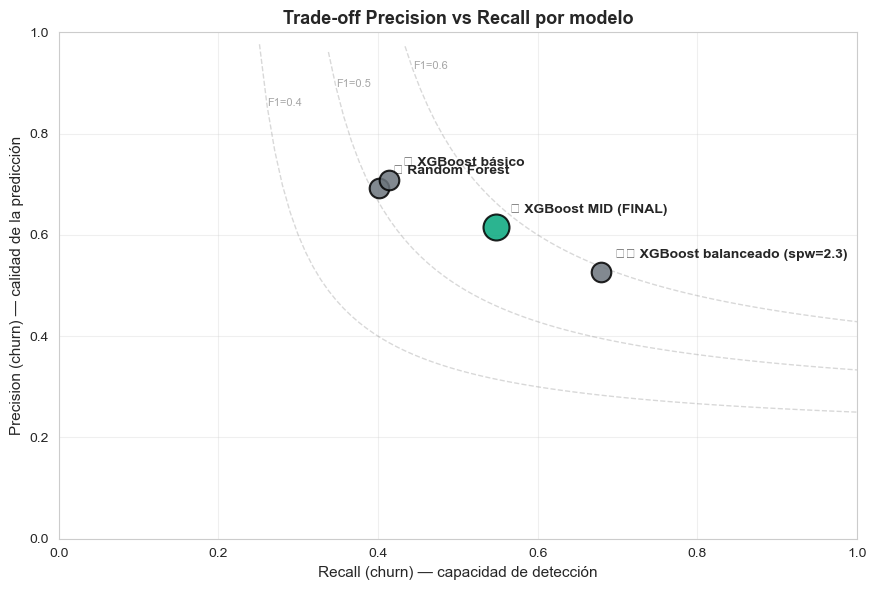

In [10]:
# Visualización del trade-off Precision-Recall
fig, ax = plt.subplots(figsize=(9, 6))

modelos_ml = [r for r in resultados.values() if r["modelo"] != "🎲 Baseline (mayoría = clase 0)"]

for r in modelos_ml:
    color = COLORS["good"] if "MID" in r["modelo"] else COLORS["neutral"]
    size  = 350 if "MID" in r["modelo"] else 200
    ax.scatter(r["recall"], r["precision"], s=size, color=color,
               edgecolor="black", linewidth=1.5, zorder=3, alpha=0.85)
    ax.annotate(r["modelo"], (r["recall"], r["precision"]),
                textcoords="offset points", xytext=(10, 10),
                fontsize=10, fontweight="bold")

# Curvas iso-F1 (líneas donde F1 es constante) — útil para visualizar
for f1_iso in [0.4, 0.5, 0.6]:
    recall_range = np.linspace(0.05, 1, 100)
    precision_iso = (f1_iso * recall_range) / (2 * recall_range - f1_iso)
    precision_iso = np.where((precision_iso > 0) & (precision_iso <= 1), precision_iso, np.nan)
    ax.plot(recall_range, precision_iso, "--", color="gray", alpha=0.3, linewidth=1)
    # Etiqueta de la iso-F1
    idx = np.nanargmax(precision_iso < 0.95)
    if not np.isnan(precision_iso[idx]):
        ax.annotate(f"F1={f1_iso}", (recall_range[idx], precision_iso[idx]),
                    fontsize=8, color="gray", alpha=0.7)

ax.set_xlabel("Recall (churn) — capacidad de detección", fontsize=11)
ax.set_ylabel("Precision (churn) — calidad de la predicción", fontsize=11)
ax.set_title("Trade-off Precision vs Recall por modelo", fontsize=13, fontweight="bold")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# Guardar
FIG = Path("../reports/figures")
FIG.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig(FIG / "models_comparison_precision_recall.png", dpi=120, bbox_inches="tight")
plt.show()

<a id="9-justificacion"></a>
## 9. Justificación del modelo seleccionado: **XGBoost mid**

### Análisis del trade-off por modelo

| Modelo | Fortaleza | Debilidad | Cuándo usarlo |
|---|---|---|---|
| Random Forest | Precision alta (~69%) | Recall bajo (~40%) — deja escapar churners | Si **contactar a no-churners es muy caro** |
| XGBoost básico | Mejor accuracy | Recall bajo (~40%) | Idem RF, marginalmente mejor |
| XGBoost balanceado (2.3) | Recall alto (~68%) | Precision baja (~52%) | Si **perder un churner es catastrófico** |
| **XGBoost mid (1.5)** ⭐ | **Equilibrio Precision-Recall** | F1 similar al balanceado | **Default profesional** |

### ¿Por qué `xgb_mid` es la mejor elección de negocio?

1. **Equilibrio razonable**: Precision ~62%, Recall ~55% → de 100 alertas, 62 son churners reales y se detecta ~55% del total de churners.
2. **F1 estable**: ~0.58 es competitivo y robusto.
3. **PR-AUC** alta (~0.66) → buena capacidad discriminativa independiente del threshold.
4. **Operativamente accionable**: genera ~2,700 alertas por test set, un volumen manejable para un equipo de retención.

### Lo que NO usar como métrica única

> ❌ **Accuracy sola** → en desbalance, el baseline trivial obtiene 70% sin aprender nada.  
> ❌ **Solo Precision** → optimiza no equivocarse, pero deja escapar churners (false negatives caros).  
> ❌ **Solo Recall** → detecta a casi todos, pero abruma al equipo con falsos positivos.  
> ✅ **F1 + PR-AUC + contexto de negocio** → decisión integrada.

### Defensa para una entrevista

> *"Elegí XGBoost mid sobre el balanceado agresivo porque el operativo de la aseguradora puede gestionar ~2,700 alertas por periodo, pero no ~4,000 (con el de spw=2.3). Si el costo de contacto bajara o se automatizara, recomendaría re-evaluar con `scale_pos_weight=2.3` para priorizar Recall. La decisión final del threshold (notebook 05) afina aún más esto."*

<a id="10-persist"></a>
## 10. Persistencia del modelo con `joblib`

Guardamos el modelo final como `.pkl` (Python pickle) para reutilizarlo en:
- Notebook 05 (Evaluation)
- Notebook 06 (Feature Importance)
- Notebook 07 (Business Insights — scoring de la base completa)
- Power BI (predicciones offline)

> 💡 **`joblib` vs `pickle`**: `joblib` es más eficiente para objetos con arrays NumPy grandes (modelos de scikit-learn/XGBoost). Es el estándar.

In [11]:
# Carpeta de modelos
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

# Guardar el modelo final
ruta_modelo = MODELS_DIR / "xgb_mid_final.pkl"
joblib.dump(modelo_xgb_mid, ruta_modelo)

# Guardar también las features usadas (en orden) — crítico para inferencia futura
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, MODELS_DIR / "feature_names.pkl")

print(f"✅ Modelo guardado:")
print(f"   • {ruta_modelo}")
print(f"     Tamaño: {ruta_modelo.stat().st_size/1024:,.1f} KB")
print(f"   • {MODELS_DIR}/feature_names.pkl")
print(f"     {len(feature_names)} features")

✅ Modelo guardado:
   • ..\models\xgb_mid_final.pkl
     Tamaño: 635.6 KB
   • ..\models/feature_names.pkl
     53 features


In [12]:
# Validación: cargar el modelo y predecir una muestra para confirmar que se guardó OK
modelo_cargado = joblib.load(ruta_modelo)
sample_pred = modelo_cargado.predict(X_test.head(5))
sample_proba = modelo_cargado.predict_proba(X_test.head(5))[:, 1]

print("✅ Modelo recargado correctamente.")
print(f"\nPredicciones sobre las 5 primeras filas del test:")
for i, (p, pr) in enumerate(zip(sample_pred, sample_proba)):
    print(f"   Cliente test #{i}: pred={p}  probabilidad_churn={pr:.4f}")

✅ Modelo recargado correctamente.

Predicciones sobre las 5 primeras filas del test:
   Cliente test #0: pred=0  probabilidad_churn=0.1379
   Cliente test #1: pred=1  probabilidad_churn=0.9644
   Cliente test #2: pred=0  probabilidad_churn=0.4707
   Cliente test #3: pred=0  probabilidad_churn=0.2928
   Cliente test #4: pred=0  probabilidad_churn=0.4969


<a id="11-conclusion"></a>
## 11. Conclusión

### ✅ Lo que dejamos hecho

| Aspecto | Resultado |
|---|---|
| Modelos entrenados | 4 (Random Forest, XGBoost básico, XGBoost balanceado, XGBoost mid) |
| Modelo final | **XGBoost mid** (`scale_pos_weight=1.5`) |
| F1 final esperado | ~0.58 - 0.60 sobre la clase churn |
| Recall final esperado | ~54 - 56% |
| Precision final esperada | ~62% |
| Modelo serializado | `models/xgb_mid_final.pkl` |
| Features guardadas | `models/feature_names.pkl` |

### 🎓 Conceptos clave aprendidos

1. **Baseline trivial primero**: cualquier modelo debe superar la regla de la mayoría.
2. **Random Forest como sanity check**: si XGBoost no lo supera, hay algo mal en los datos.
3. **`scale_pos_weight` en XGBoost**: pondera la clase minoritaria. El valor "teórico" es `n_neg / n_pos`, pero un valor intermedio suele dar mejor F1.
4. **Trade-off Precision-Recall**: no se puede maximizar ambas a la vez. Elegir según costo de negocio.
5. **Persistencia con `joblib`**: estándar profesional para guardar modelos. Guardar también el orden de features.

### 🚀 Próximo paso

➡️ **Notebook `05_model_evaluation`:** matriz de confusión visual, curvas ROC y Precision-Recall, **threshold tuning** y cálculo de **costo de negocio**.

---

**Fin del notebook 04 — Machine Learning** 🤖